**HOME WORK:**

I chose a STUDENT PERFORMANCE PREDICTION, I coined or rather abbreviated it **SPP** for short.

So, this is my attempt at that. I watched the previous class recordings, youtube videos, asked chatgpt, claude & gemini for help as well as my brain. lol

here i go:

In [1]:
#step 1: import everything, basically all the libraries we used in class.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('/content/Adjusted Student performance.csv', on_bad_lines='skip', low_memory=False) #load data

## ***1. DATA ANALYSIS AND CHECKS***

In [4]:
df.head() #displays first five rows. more like quick inspection, you get?

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [5]:
df.shape #check rows & column number

(49999, 6)

In [ ]:
#ok. i got my data set from kaggle and it was very large
#about 1 million rows !!?!
#can you imagine? so, i trimmed it to like 50k row.

In [6]:
df.isnull().sum() #most of these comments are more for me than the supervisor #still checks but missing data

,0
student_id,0
weekly_self_study_hours,0
attendance_percentage,0
class_participation,0
total_score,0
grade,0


In [7]:
df.describe() #does a quick analysis of the data, mean, standard deviation etc
#but if we said df.describe().T it will flip columns & rows

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000
mean,25000.000000,15.038717,84.658627,5.986148,84.300992
std,14433.612391,6.894157,9.446686,1.956986,15.441475
min,1.000000,0.000000,50.000000,0.000000,14.600000
25%,12500.500000,10.200000,78.200000,4.700000,73.900000
50%,25000.000000,15.000000,84.900000,6.000000,87.500000
75%,37499.500000,19.700000,91.700000,7.300000,100.000000
max,49999.000000,40.000000,100.000000,10.000000,100.000000


In [8]:
df.duplicated().sum() #checks for duplicate rows basically.

np.int64(0)

In [9]:
df.isna().sum()[df.isna().sum() > 0] #checks data finds columns with missing stuffs essentially, slighty complicated maths.

,0


In [10]:
#Check what distinct and unique categories they contain and how many different categories there are in each.
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(col)
    print('Total Unique Values : ',df[col].unique())
    print('Total Numerical Unique Values : ',df[col].nunique())

grade
Total Unique Values :  ['A' 'B' 'C' 'D' 'F']
Total Numerical Unique Values :  5


In [12]:
# Removing columns not needed. #for example the student id is not neccessary just by going through the csv file.
df = df.drop(columns = ['student_id'])

## ***2. START EDA: Exploratory Data Analysis***

In [14]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
#seprates integers (whole numbers) int64 or float64 decimal numbers

cat_cols = df.select_dtypes(include='object').columns

print(f"Total num_cols are : ",len(num_cols))
print(f"Total cat_cols are : ",len(cat_cols))

Total num_cols are :  4
Total cat_cols are :  1


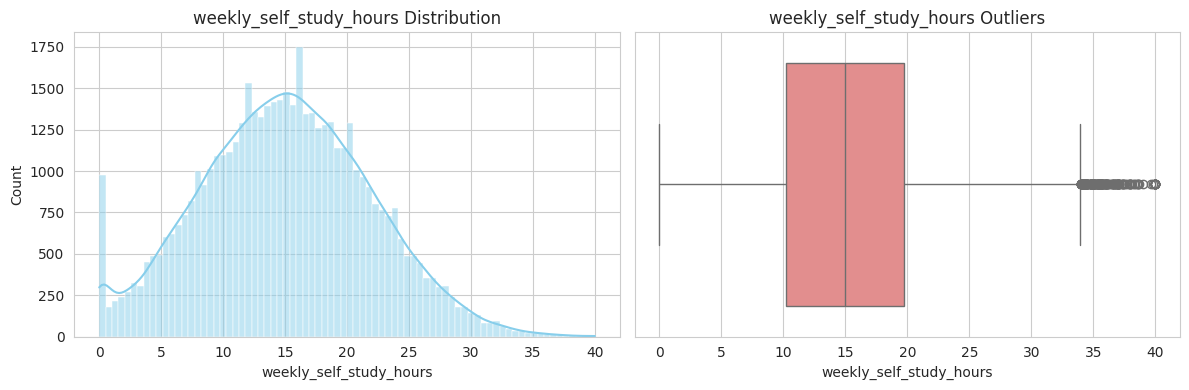

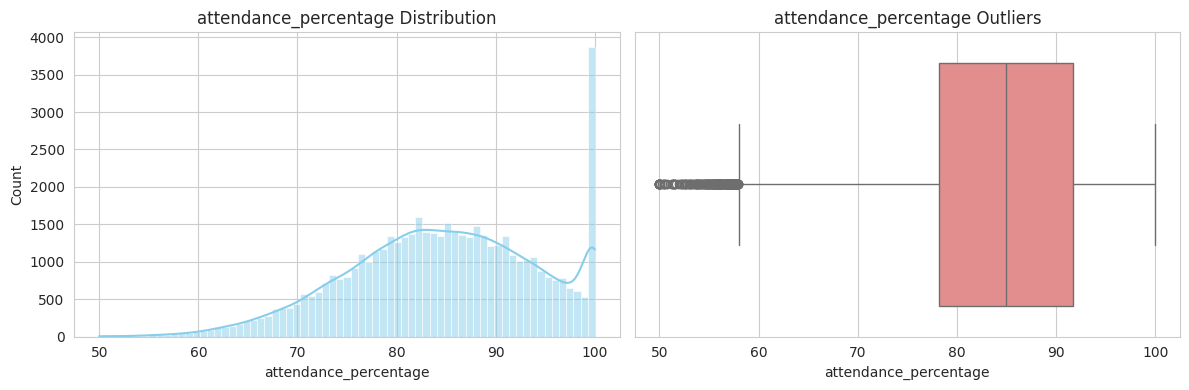

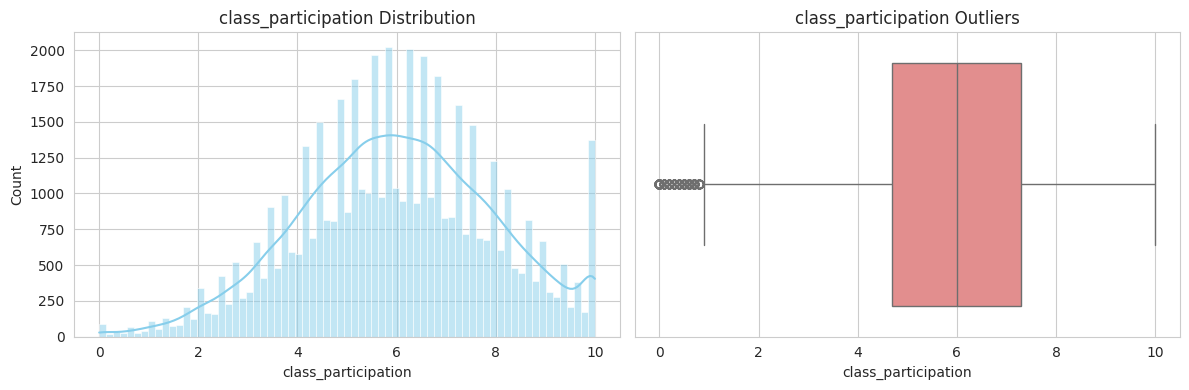

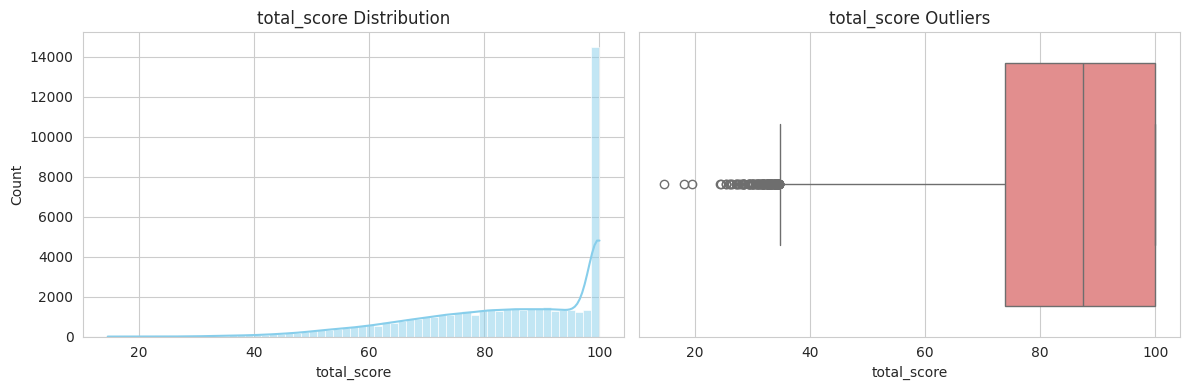

In [15]:
# Plot Histograms and Boxplots side-by-side for each numerical column
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram with KDE curve
    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'{col} Distribution')

    # Boxplot for outliers (abnormalities or far from others)
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'{col} Outliers')

    plt.tight_layout()
    plt.show()

In [19]:
import math #import math as the name implies

def count_plot(cols):
    n = len(cols)
    rows = math.ceil(n / 2)

    plt.figure(figsize=(14, 5 * rows))

    for i, col in enumerate(cols, 1):
        plt.subplot(rows, 2, i)

        sns.countplot(
            data=df,
            x=col,
            order=df[col].value_counts().index,
            legend=True
        )

        plt.title(f'{col} Frequency')
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

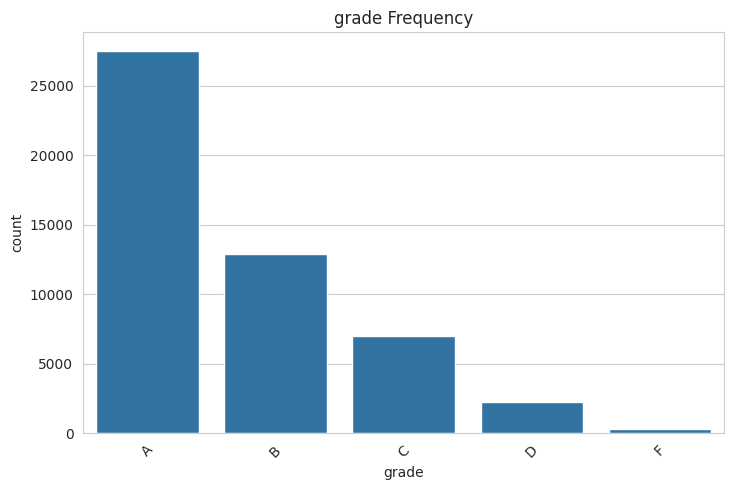

In [20]:
count_plot(cat_cols) #visualize the above

### **NUMERICAL CORRELATION**

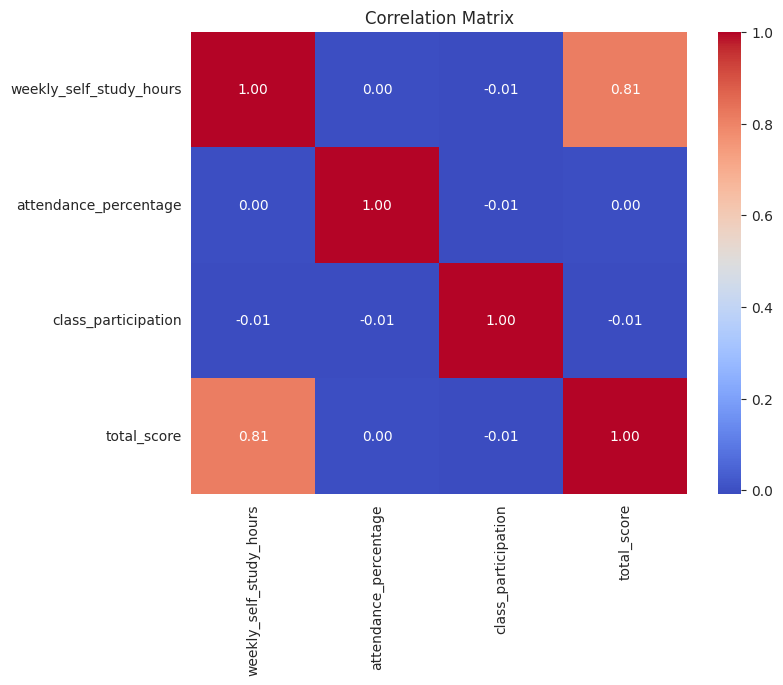

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

In [22]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split

In [23]:
from scipy import stats
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
z_scores = np.abs(stats.zscore(df[num_cols], nan_policy='omit'))
outliers = (z_scores > 3).sum()
print(outliers)

505


In [24]:
# Remove outliers using IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
    ]

In [25]:
z_scores = np.abs(stats.zscore(df[num_cols], nan_policy='omit'))
outliers = (z_scores > 3).sum()
print(outliers)

160


## ***3. ONE-HOT ENCODING***

In [26]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [27]:
X = df.drop('total_score', axis=1)
y = df['total_score']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

STANDARD SCALING

In [29]:
# Implement StandardScaler to eliminate scaling bias across numerical features.

all_numeric_cols  = X_train.select_dtypes(include='number').columns # keep only non-binary numeric columns and scale them

cols_to_scale  = [c for c in all_numeric_cols  if df[c].nunique() > 2]

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transform ONLY if using fit_transform so X_test uses it's own mean value
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [30]:
X_train = pd.DataFrame(X_train)
X_train.head(2)

,weekly_self_study_hours,attendance_percentage,class_participation,grade_B,grade_C,grade_D,grade_F
49502,-0.564549,0.734358,-0.944041,1,0,0,0
932,-1.492742,-1.899234,-2.036135,0,0,1,0


In [31]:
df.shape

(49318, 8)

Machine Learning and Hyperparameter Tuning

In [32]:
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score

# Linear Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Tree-Based Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Boosting Models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [33]:
models = {

    # ============================
    # Linear Models (Baseline)
    # ============================
    "Linear Regression": LinearRegression(
        n_jobs=-1
    ),

    "Ridge Regression": Ridge(),

    "Lasso Regression": Lasso(),

    "ElasticNet Regression": ElasticNet(),

    # ============================
    # Tree-Based Models
    # ============================
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),

    # ============================
    # Boosting Models
    # ============================
    "XGBoost": XGBRegressor(
        random_state=42,
        objective='reg:squarederror',
        tree_method='hist'
    ),

    "LightGBM": LGBMRegressor(
        random_state=42,
        force_col_wise=True,
        verbose=-1
    )
}

In [34]:
param_grids = {

    # ============================
    # Linear Models
    # ============================
    "Linear Regression": {},

    "Ridge Regression": {
        "alpha": [0.01, 0.1, 1, 10, 100]
    },

    "Lasso Regression": {
        "alpha": [0.001, 0.01, 0.1, 1, 10]
    },

    "ElasticNet Regression": {
        "alpha": [0.001, 0.01, 0.1, 1],
        "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    },

    # ============================
    # Tree-Based Models
    # ============================
    "Decision Tree": {
        "max_depth": [3, 5, 7, 10, 15, None],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 5, 10],
        "criterion": ["squared_error", "friedman_mse"]
    },

    "Random Forest": {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"]
    },

    # ============================
    # Boosting Models
    # ============================
    "XGBoost": {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [3, 4, 5, 6, 7],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.6, 0.7, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
        "gamma": [0, 0.1, 0.2]
    },

    "LightGBM": {
        "n_estimators": [100, 200, 300, 500],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "num_leaves": [15, 31, 50, 70],
        "max_depth": [-1, 3, 5, 7, 10],
        "min_child_samples": [5, 10, 20, 30],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0]
    }
}

In [35]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [36]:
best_model = None
best_score = -float("inf")
best_model_name = ""

results = {}

for name, model in models.items():

    print(f"\nRunning RandomizedSearchCV for {name}...")

    random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grids[name],
    cv=kf,
    scoring='r2',
    n_jobs=1,
    n_iter=20 if model == "LightGBM" else 50,
    random_state=42
    )

    random_search.fit(X_train, y_train)

    results[name] = {
        "Best Params": random_search.best_params_,
        "Best CV Score (R2)": random_search.best_score_
    }

    print(name)
    print("Best Params:", random_search.best_params_)
    print("Best CV Score (R2):", random_search.best_score_)

    # STORE ONLY BEST MODEL
    if random_search.best_score_ > best_score:
        best_score = random_search.best_score_
        best_model = random_search.best_estimator_
        best_model_name = name


Running RandomizedSearchCV for Linear Regression...
Linear Regression
Best Params: {}
Best CV Score (R2): 0.9308329643593058

Running RandomizedSearchCV for Ridge Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=50. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=50. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Ridge Regression
Best Params: {'alpha': 0.01}
Best CV Score (R2): 0.9308329667579466

Running RandomizedSearchCV for Lasso Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=50. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Lasso Regression
Best Params: {'alpha': 0.001}
Best CV Score (R2): 0.9308317716444584

Running RandomizedSearchCV for ElasticNet Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 20 is smaller than n_iter=50. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


ElasticNet Regression
Best Params: {'l1_ratio': 0.9, 'alpha': 0.001}
Best CV Score (R2): 0.930787283371334

Running RandomizedSearchCV for Decision Tree...
Decision Tree
Best Params: {'min_samples_split': 5, 'min_samples_leaf': 10, 'max_depth': 7, 'criterion': 'squared_error'}
Best CV Score (R2): 0.9316604508997657

Running RandomizedSearchCV for Random Forest...
Random Forest
Best Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}
Best CV Score (R2): 0.9315636049301744

Running RandomizedSearchCV for XGBoost...
XGBoost
Best Params: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1.0}
Best CV Score (R2): 0.9321367204366986

Running RandomizedSearchCV for LightGBM...
LightGBM
Best Params: {'subsample': 1.0, 'num_leaves': 15, 'n_estimators': 300, 'min_child_samples': 5, 'max_depth': -1, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
Best CV Score (R2): 0.9323

In [38]:
# DataFrame of results to make it more readable
results_df = pd.DataFrame(results).T
results_df.sort_values(by="Best CV Score (R2)", ascending=False)

,Best Params,Best CV Score (R2)
LightGBM,"{'subsample': 1.0, 'num_leaves': 15, 'n_estima...",0.932342
XGBoost,"{'subsample': 0.7, 'n_estimators': 500, 'max_d...",0.932137
Decision Tree,"{'min_samples_split': 5, 'min_samples_leaf': 1...",0.93166
Random Forest,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.931564
Ridge Regression,{'alpha': 0.01},0.930833
Linear Regression,{},0.930833
Lasso Regression,{'alpha': 0.001},0.930832
ElasticNet Regression,"{'l1_ratio': 0.9, 'alpha': 0.001}",0.930787


In [39]:
print("Best Model:", best_model_name)
print("Best CV Score (R2):", best_score)

Best Model: LightGBM
Best CV Score (R2): 0.9323422988602047


In [40]:
y_pred = best_model.predict(X_test)

In [41]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 3.213338015307629
RMSE: 4.000949305227929
R2 Score: 0.9306087007824116


STREAMLIT STAGE

In [48]:
import joblib

# Save the trained model
joblib.dump(best_model, 'spp_best_model.joblib')

# Save the scaler
joblib.dump(scaler, 'spp_scaler.joblib')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


Now that the model and scaler are saved, let's create the `app.py` file for your Streamlit application.

In [45]:
%%writefile app.py
app_py_content = """

import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Load the trained model and scaler
best_model = joblib.load('spp_best_model.joblib')
scaler = joblib.load('spp_scaler.joblib')

# Define the order of columns for prediction (must match X_train)
# Based on X_train.columns from the notebook state
feature_cols = [
    'weekly_self_study_hours',
    'attendance_percentage',
    'class_participation',
    'grade_B',
    'grade_C',
    'grade_D',
    'grade_F'
]

st.set_page_config(page_title="Student Performance Predictor", layout="centered")
st.title('Student Performance Prediction (SPP)')
st.write('Predict a student\'s total score based on their study habits, attendance, and class participation.')

st.subheader('Enter Student Details:')

# Input widgets for numerical features
weekly_self_study_hours = st.slider('Weekly Self-Study Hours', min_value=0.0, max_value=40.0, value=15.0, step=0.1)
attendance_percentage = st.slider('Attendance Percentage', min_value=50.0, max_value=100.0, value=85.0, step=0.1)
class_participation = st.slider('Class Participation (out of 10)', min_value=0.0, max_value=10.0, value=6.0, step=0.1)

# Input widget for categorical 'grade'
grade_options = ['A', 'B', 'C', 'D', 'F']
selected_grade = st.radio('Previous Grade (for one-hot encoding)', grade_options, index=0) # Default to 'A'

# Create a dictionary for one-hot encoded grade columns
grade_encoded = {
    'grade_B': 0,
    'grade_C': 0,
    'grade_D': 0,
    'grade_F': 0
}

# Set the corresponding grade column to 1 based on selection
if selected_grade != 'A':
    grade_encoded[f'grade_{selected_grade}'] = 1

# Create a DataFrame from user inputs
input_data = pd.DataFrame({
    'weekly_self_study_hours': [weekly_self_study_hours],
    'attendance_percentage': [attendance_percentage],
    'class_participation': [class_participation],
    'grade_B': [grade_encoded['grade_B']],
    'grade_C': [grade_encoded['grade_C']],
    'grade_D': [grade_encoded['grade_D']],
    'grade_F': [grade_encoded['grade_F']]
})

# Identify numerical columns for scaling (these must match 'cols_to_scale' from training)
# Based on `cols_to_scale` variable from the notebook state
numerical_features_for_scaling = [
    'weekly_self_study_hours',
    'attendance_percentage',
    'class_participation'
]

# Scale the numerical features using the loaded scaler
input_data[numerical_features_for_scaling] = scaler.transform(input_data[numerical_features_for_scaling])

# Ensure column order matches the training data (important for prediction)
input_data = input_data[feature_cols]

if st.button('Predict Total Score'):
    prediction = best_model.predict(input_data)[0]
    st.success(f'Predicted Total Score: **{prediction:.2f}**')
    st.balloons()

st.markdown("""
---
#### How to run this application:
#1.  Save the `spp_best_model.joblib` and `spp_scaler.joblib` files (already done by the previous cell).
##2.  Open your terminal or command prompt.
#3.  Navigate to the directory where `app.py`, `spp_best_model.joblib`, and `spp_scaler.joblib` are saved.
#4.  Run the command: `streamlit run app.py`
""")


Overwriting app.py


In [49]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Load the trained model and scaler
best_model = joblib.load('spp_best_model.joblib')
scaler = joblib.load('spp_scaler.joblib')

# Define the order of columns for prediction (must match X_train)
# Based on X_train.columns from the notebook state
feature_cols = [
    'weekly_self_study_hours',
    'attendance_percentage',
    'class_participation',
    'grade_B',
    'grade_C',
    'grade_D',
    'grade_F'
]

st.set_page_config(page_title="Student Performance Predictor", layout="centered")
st.title('Student Performance Prediction (SPP)')
st.write('Predict a student\'s total score based on their study habits, attendance, and class participation.')

st.subheader('Enter Student Details:')

# Input widgets for numerical features
weekly_self_study_hours = st.slider('Weekly Self-Study Hours', min_value=0.0, max_value=40.0, value=15.0, step=0.1)
attendance_percentage = st.slider('Attendance Percentage', min_value=50.0, max_value=100.0, value=85.0, step=0.1)
class_participation = st.slider('Class Participation (out of 10)', min_value=0.0, max_value=10.0, value=6.0, step=0.1)

# Input widget for categorical 'grade'
grade_options = ['A', 'B', 'C', 'D', 'F']
selected_grade = st.radio('Previous Grade (for one-hot encoding)', grade_options, index=0) # Default to 'A'

# Create a dictionary for one-hot encoded grade columns
grade_encoded = {
    'grade_B': 0,
    'grade_C': 0,
    'grade_D': 0,
    'grade_F': 0
}

# Set the corresponding grade column to 1 based on selection
if selected_grade != 'A':
    grade_encoded[f'grade_{selected_grade}'] = 1

# Create a DataFrame from user inputs
input_data = pd.DataFrame({
    'weekly_self_study_hours': [weekly_self_study_hours],
    'attendance_percentage': [attendance_percentage],
    'class_participation': [class_participation],
    'grade_B': [grade_encoded['grade_B']],
    'grade_C': [grade_encoded['grade_C']],
    'grade_D': [grade_encoded['grade_D']],
    'grade_F': [grade_encoded['grade_F']]
})

# Identify numerical columns for scaling (these must match 'cols_to_scale' from training)
# Based on `cols_to_scale` variable from the notebook state
numerical_features_for_scaling = [
    'weekly_self_study_hours',
    'attendance_percentage',
    'class_participation'
]

# Scale the numerical features using the loaded scaler
input_data[numerical_features_for_scaling] = scaler.transform(input_data[numerical_features_for_scaling])

# Ensure column order matches the training data (important for prediction)
input_data = input_data[feature_cols]

if st.button('Predict Total Score'):
    prediction = best_model.predict(input_data)[0]
    st.success(f'Predicted Total Score: **{prediction:.2f}**')
    st.balloons()

st.markdown("""
---
#### How to run this application:
1.  Save the `spp_best_model.joblib` and `spp_scaler.joblib` files (already done by the previous cell).
2.  Open your terminal or command prompt.
3.  Navigate to the directory where `app.py`, `spp_best_model.joblib`, and `spp_scaler.joblib` are saved.
4.  Run the command: `streamlit run app.py`
""")

Overwriting app.py


In [50]:
%%writefile requirements.txt

pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
lightgbm
streamlit
joblib

Overwriting requirements.txt
